# We will make a GPT (Generative Pretrained Transformer) here including all the requreied componenets
# 

In [1]:
#Specifying  GPT with Dict

GPT_Config_124M= {

    "vocab_size" : 50257, #Vocabulary size for GPT2
    "context_length" : 1024, # Context Length
    "emb_dim":768, # Embedding Dimension
    "n_heads":12, # 12 attention heads
    "n_layers":12, # Number of layers
    "drop_rate":0.1, #Dropout rate
    "qkv_bias": False #Query,key,value bias

}

In [2]:
# Now a dummy class for the whole GPT architecture

import torch
import torch.nn as nn

class DummyGPTModel(nn.Module):
    def __init__(self,cfg): # here cfg is the configuration we defined above, more compact way
        super().__init__()
        self.tok_emb=nn.Embedding(cfg["vocab_size"],cfg["emb_dim"]) # we define token embeddings here
        self.pos_emb=nn.Embedding(cfg["context_length"],cfg["emb_dim"]) # we define the pos embedding here
        self.drop_emb=nn.Dropout(cfg["drop_rate"]) # the dropout rate

        #now the placeholder for transformer block -> this is the actual stufff we did in previous ch, meaning
        # the sself attention stuff etc, but for now a placeholder 

        self.trf_block=nn.Sequential(
            *[DummyTransformerBlock(cfg)
            for _ in range(cfg["n_layers"])]
        )

        self.final_norm= DummyLayerNorm(cfg["emb_dim"])

        self.out_head=nn.Linear(cfg["emb_dim"],cfg["vocab_size"],bias=False)

    def forward(self,in_idx):
        batch_size,seq_len=in_idx.shape
        tok_emb=self.tok_emb(in_idx)
        pos_emb=self.pos_emb(torch.arange(seq_len,device=in_idx.device))

        x=tok_emb+pos_emb #embedded vector?
        x=self.drop_emb(x)
        x=self.trf_block(x)
        x=self.final_norm(x)

        logits=self.out_head(x)
        return logits
    

# classes transformer block and layernorm, placeholders

class DummyTransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()

    def forward(self,x):
        return x #just return for now
    

class DummyLayerNorm(nn.Module):
    def __init__(self,normalized_shape,eps=1e-5):
        super().__init__()

    def forward(self,x):
        return x    



In [3]:
#Running the class and feeding it some input
# we will prepare 2 batches of inputs and utilize tiktoken from ch2

import tiktoken
tokenizer=tiktoken.get_encoding("gpt2")
batch=[]
txt1="Every effort moves you"
txt2="Every day holds a"

batch.append(torch.tensor(tokenizer.encode(txt1)))
batch.append(torch.tensor(tokenizer.encode(txt2)))

print(batch)
batch=torch.stack(batch,dim=0)
print("stacked batch: ",batch)

#nOW Intiliazing a dummy 124M parameter GPT  model   instance and feeding it this batch

torch.manual_seed(123)
model=DummyGPTModel(GPT_Config_124M)
logits=model(batch)
print("Output shape: ", logits.shape)
print("Output: ",logits)


             

[tensor([6109, 3626, 6100,  345]), tensor([6109, 1110, 6622,  257])]
stacked batch:  tensor([[6109, 3626, 6100,  345],
        [6109, 1110, 6622,  257]])
Output shape:  torch.Size([2, 4, 50257])
Output:  tensor([[[-0.9289,  0.2748, -0.7557,  ..., -1.6070,  0.2702, -0.5888],
         [-0.4476,  0.1726,  0.5354,  ..., -0.3932,  1.5285,  0.8557],
         [ 0.5680,  1.6053, -0.2155,  ...,  1.1624,  0.1380,  0.7425],
         [ 0.0447,  2.4787, -0.8843,  ...,  1.3219, -0.0864, -0.5856]],

        [[-1.5474, -0.0542, -1.0571,  ..., -1.8061, -0.4494, -0.6747],
         [-0.8422,  0.8243, -0.1098,  ..., -0.1434,  0.2079,  1.2046],
         [ 0.1355,  1.1858, -0.1453,  ...,  0.0869, -0.1590,  0.1552],
         [ 0.1666, -0.8138,  0.2307,  ...,  2.5035, -0.3055, -0.3083]]],
       grad_fn=<UnsafeViewBackward0>)


# D10 --> We are doing layer normalization

In [4]:
# we need a unit variance where mean is 0 and variance is 1

# we will be recreating book example with 5 inputs and 6 outputs and negatives are replaced 
# by zero using the nn.reLU function, ReLU is an activation function and there are several like this

torch.manual_seed(123)
batch_example=torch.randn(2,5) # create 2 examples with 5 dimensions(tokens) each
layer= nn.Sequential(nn.Linear(5,6),nn.ReLU())
out=layer(batch_example)
print(out)


# The output is a 6 dimension output from 5 inputs, know we will need to apply normalization layer
# first checking the current mean and variance

mean = out.mean(dim=-1,keepdim=True)
var= out.var(dim=-1,keepdim=True)
print("Mean: ", mean)
print("Variance: ", var)



#Now we apply layer normalization to the outputs and check the mean and variance 
# we do this by subtracting the mean from output and dvifing by square root of variance (standard deviation)

out_norm=(out-mean)/torch.sqrt(var)
print("Normalized layer output: ",out_norm)

torch.set_printoptions(sci_mode=False)
mean = out_norm.mean(dim=-1,keepdim=True)
var= out_norm.var(dim=-1,keepdim=True)
print("Mean: ", mean)
print("Variance: ", var)


tensor([[0.2260, 0.3470, 0.0000, 0.2216, 0.0000, 0.0000],
        [0.2133, 0.2394, 0.0000, 0.5198, 0.3297, 0.0000]],
       grad_fn=<ReluBackward0>)
Mean:  tensor([[0.1324],
        [0.2170]], grad_fn=<MeanBackward1>)
Variance:  tensor([[0.0231],
        [0.0398]], grad_fn=<VarBackward0>)
Normalized layer output:  tensor([[ 0.6159,  1.4126, -0.8719,  0.5872, -0.8719, -0.8719],
        [-0.0189,  0.1121, -1.0876,  1.5173,  0.5647, -1.0876]],
       grad_fn=<DivBackward0>)
Mean:  tensor([[    0.0000],
        [    0.0000]], grad_fn=<MeanBackward1>)
Variance:  tensor([[1.0000],
        [1.0000]], grad_fn=<VarBackward0>)


In [5]:
# Now implementing a class to use in GPT model later

class LayerNorm(nn.Module):
    def __init__(self, emb_dim):
        super().__init__()
        self.eps=1e-5 # to avoid division by zero errors
        self.scale=nn.Parameter(torch.ones(emb_dim))
        self.shift = nn.Parameter(torch.zeros(emb_dim))

    def forward(self,x):
        mean=x.mean(dim=-1,keepdim=True)
        var=x.var(dim=-1,keepdim=True,unbiased=False)
        norm_x=(x-mean)/torch.sqrt(var+self.eps)
        return self.scale*norm_x+self.shift
    

#checking the class
Layer_n=LayerNorm(emb_dim=5)
out_Layer_n=Layer_n(batch_example)
mean=out_Layer_n.mean(dim=-1,keepdim=True)
var=out_Layer_n.var(dim=-1,unbiased=False,keepdim=True)
print("Mean: ", mean)
print("Variance: ", var)



Mean:  tensor([[    -0.0000],
        [     0.0000]], grad_fn=<MeanBackward1>)
Variance:  tensor([[1.0000],
        [1.0000]], grad_fn=<VarBackward0>)


# now the GELU module, it is more performative and is smoother curve than reLU

In [6]:
# Now thwe GELU class
class GELU(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self,x):
        return 0.5 * x * (1+ torch.tanh(torch.sqrt(torch.tensor(2.0/torch.pi))* 
                                        (x+0.044715*torch.pow(x,3))))
        

<function matplotlib.pyplot.show(close=None, block=None)>

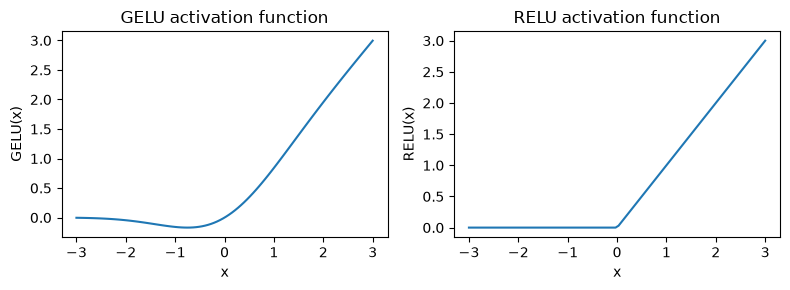

In [7]:
# To compare GELU and Normalizing layer
import matplotlib.pyplot as plt
gelu,relu= GELU(),nn.ReLU()

x= torch.linspace(-3,3,100)
y_gelu,y_relu=gelu(x),relu(x)

plt.figure(figsize=(8, 3))
for i,(y,label) in enumerate(zip([y_gelu,y_relu],["GELU","RELU"]),1):
    plt.subplot(1,2,i)
    plt.plot(x,y)
    plt.title(f"{label} activation function")
    plt.xlabel("x")
    plt.ylabel(f"{label}(x)")
    plt.grid=(True)

plt.tight_layout()
plt.show




# D12 Implementing feedforward using GELU

In [8]:
# we will make a feedforward class that applies GELU and returns the emb dimension layers

class Feedforward(nn.Module):
    def __init__(self,cfg):
        super().__init__()
        self.layers=nn.Sequential(nn.Linear(cfg["emb_dim"],4*cfg["emb_dim"]),
                                  GELU(),
                                  nn.Linear(4*cfg["emb_dim"],cfg["emb_dim"]))
        
    def forward(self,x):
        return self.layers(x)
    

# testing it
ffn=Feedforward(GPT_Config_124M) # defining feedforward with GPT
x=torch.rand(2,3,768) # making a batch of 2 batch size, 3 tokens and 768 emb dim
out=ffn(x)
print(out.shape)

        

torch.Size([2, 3, 768])


# D13: Shortcuts and completing the transformer block

In [9]:
# Shortcuts example, in shortcuts we just add the output of one layer to the gradient of another

class ExampleNeuralNet(nn.Module):
    def __init__(self,layer_size,use_shortcut):
        super().__init__()
        self.use_shortcut = use_shortcut
        self.layers=nn.ModuleList([
            nn.Sequential(nn.Linear(layer_size[0],layer_size[1]),GELU()),
            nn.Sequential(nn.Linear(layer_size[1],layer_size[2]),GELU()),
            nn.Sequential(nn.Linear(layer_size[2],layer_size[3]),GELU()),
            nn.Sequential(nn.Linear(layer_size[3],layer_size[4]),GELU()),
            nn.Sequential(nn.Linear(layer_size[4],layer_size[5]),GELU()),
        ])
    def forward(self,x):
        for layer in self.layers:
            layer_output=layer(x)
            if self.use_shortcut and x.shape ==layer_output.shape:
                x=x+layer_output
            else:
                x= layer_output
        return x



#testing the examp0le nerual net backpropagation
layer_sizes=[3,3,3,3,3,1] # last is 1 to get 1 output
sample_input=torch.tensor([[1.,0.,-1.]])
torch.manual_seed(123)
model_without_shortcut=ExampleNeuralNet(layer_sizes,use_shortcut=False)

# now implementing a function to calculate gradient
def print_gradient(model,x):
    output = model(x)
    target=torch.tensor([[0.]])

    loss=nn.MSELoss()
    loss=loss(output,target)
    loss.backward() # backward pass to calculate
    for name,param in model.named_parameters():
        if 'weight' in name:
            print(f"{name} gradient mean: {param.grad.abs().mean().item()}")



print_gradient(model_without_shortcut, sample_input)

print("\nNow with the shortcut enabled")
# now with shortcut enabled
torch.manual_seed(123)
model_with_shortcut=ExampleNeuralNet(layer_sizes,use_shortcut=True)
print_gradient(model_with_shortcut, sample_input)





# 


layers.0.0.weight gradient mean: 0.00020173587836325169
layers.1.0.weight gradient mean: 0.0001201116101583466
layers.2.0.weight gradient mean: 0.0007152041653171182
layers.3.0.weight gradient mean: 0.001398873864673078
layers.4.0.weight gradient mean: 0.005049646366387606

Now with the shortcut enabled
layers.0.0.weight gradient mean: 0.22169792652130127
layers.1.0.weight gradient mean: 0.20694106817245483
layers.2.0.weight gradient mean: 0.32896995544433594
layers.3.0.weight gradient mean: 0.2665732502937317
layers.4.0.weight gradient mean: 1.3258541822433472


# Implementing the Transformer class

In [10]:
# importing the MultiAttentionHead class 
from MAH import MultiAttentionHead

class TransformerBlock(nn.Module):
    def __init__(self,cfg):
        super().__init__()
        self.att=MultiAttentionHead(
            dim_in=cfg["emb_dim"],
            dim_out=cfg["emb_dim"],
            context_length=cfg["context_length"],
            num_heads=cfg["n_heads"],
            dropout=cfg["drop_rate"],
            qkv_bias=cfg["qkv_bias"]
        )

        self.ff=Feedforward(cfg)
        self.norm1=LayerNorm(cfg["emb_dim"])
        self.norm2=LayerNorm(cfg["emb_dim"])
        self.drop_shortcut=nn.Dropout(cfg["drop_rate"])

    def forward(self,x):
    
        shortcut=x
        # shortcut for the attention module
        x=self.norm1(x)
        x=self.att(x)
        x=self.drop_shortcut(x)
        x=x+shortcut

        # shortcut for the feedforward module
        x=self.norm2(x)
        x=self.ff(x)
        x=self.drop_shortcut(x)
        x=x+shortcut

        return x


# feeding it data
torch.manual_seed(123)
x=torch.rand(2,4,768)
block=TransformerBlock(GPT_Config_124M)
output= block(x)

print("Input Shape: ", x.shape)
print("Output Shape: ",output.shape)

# the output and input dimensions are same, but the context/flavour of the 768 embeddings for each word
#  is adjusted and is the trained parameters


    


Input Shape:  torch.Size([2, 4, 768])
Output Shape:  torch.Size([2, 4, 768])


# D14 We will now make a complete GPT model with actual transformer class and layernorm class

In [11]:
# Actual working GPT model




class GPT_Model(nn.Module):
    def __init__(self,cfg):
        super().__init__()
        # definiing token emb and pos emb
        self.tok_emb=nn.Embedding(cfg["vocab_size"],cfg["emb_dim"])
        self.pos_emb=nn.Embedding(cfg["context_length"],cfg["emb_dim"])

        #dropout rate
        self.drop_emb=nn.Dropout(cfg["drop_rate"])

        #now the transformer block with MHA,ReLU,GELU,etc

        self.trf_block=nn.Sequential(
            *[TransformerBlock(cfg)
            for _ in range(cfg["n_layers"])])
        

        # mpw the layer normalization
        self.layer_norm= LayerNorm(cfg["emb_dim"])

        # output projector to vocab
        self.out_head=nn.Linear(cfg["emb_dim"],cfg["vocab_size"],bias=False)


    def forward(self,in_idx):
       # getting batch size and seq length
     batch_size,seq_len= in_idx.shape # eg [2,8,768] will assign 2 batch size and 8 tokens as seq_len
     # tok emb and pos emb
     tok_emb=self.tok_emb(in_idx)            # allows to train oc CPU or GPU wherever is the data sitting on
     pos_emb=self.pos_emb(torch.arange(seq_len,device=in_idx.device))

     # now emb vector
     x=tok_emb+pos_emb
     #applying the blocks
     x=self.drop_emb(x)
     x=self.trf_block(x)
     x=self.layer_norm(x)

     # now the logits
     logits=self.out_head(x)

     return logits




In [12]:
#testing the class GPT model with text
torch.manual_seed(123)

model=GPT_Model(GPT_Config_124M)

print (txt1,txt2)
print (batch)

out=model(batch)
print("Input batch: ",batch)
print("\n Output Shape: ",out.shape)
print("\n Output: ",out)

Every effort moves you Every day holds a
tensor([[6109, 3626, 6100,  345],
        [6109, 1110, 6622,  257]])
Input batch:  tensor([[6109, 3626, 6100,  345],
        [6109, 1110, 6622,  257]])

 Output Shape:  torch.Size([2, 4, 50257])

 Output:  tensor([[[    -0.4487,     -0.0144,     -0.2110,  ...,     -0.1215,
              -0.4767,     -0.0802],
         [     0.5670,     -0.6195,     -0.6903,  ...,     -0.6479,
              -0.3735,     -0.0652],
         [     0.7070,      0.2949,     -0.3357,  ...,      0.1182,
              -0.7712,     -0.0297],
         [    -0.8020,      0.5040,     -0.3593,  ...,      1.0951,
               0.1978,     -0.3341]],

        [[    -0.0010,     -0.1322,     -0.0453,  ...,     -0.2872,
              -0.2124,     -0.1342],
         [     0.2180,     -0.0051,      0.2116,  ...,      0.8565,
              -0.3148,      0.3522],
         [     0.7235,      0.6672,     -0.2420,  ...,      0.4453,
               0.1017,     -0.1591],
         [    -0

In [13]:
# checking the total parameters
total_params=sum(p.numel() for p in model.parameters())
print ("Total number of Parameters: ",total_params)

# it is 163M but its supposed to be 124M 
#checking tok_emb and out_head shapes
print("Token embedding layer shape: ",model.tok_emb.weight.shape)
print("Output head layer shape: ",model.out_head.weight.shape)

# both are 50257x768 and each is approx 38.6M (85M is in the transformer block)
# so that means output head is just recreating the tok emb shape and the extra param is from it
# # we can optimize it by reusing the tok emb param for the out head

total_params_gpt2=(total_params-sum(p.numel()
                 for p in model.out_head.parameters()) # subtracting the out_head params
                  )
print("Total trainable Parameters: ", total_params_gpt2) 


# no of parameters in transformer block
total_params_trf=sum(p.numel() for p in model.trf_block.parameters() )
print("Total Parameters in transformer block : ", total_params_trf) 

# no of parameters in feedforward
total_params_ff=sum(p.numel() for p in model.trf_block[0].ff.parameters())
print("Total Parameters in transformer block : ", total_params_ff) 

# no of parameters in MHA
total_params_mha=sum(p.numel() for p in model.trf_block[0].att.parameters())
print("Total Parameters in transformer block : ", total_params_mha) 


# Our model is 163M , we can reduce to 124M by weight tying, but keeping both seperate leads to better training,
#but requires more resources so a tradeoff between how big the model you want to train and the system cofig
# Now checking the mem requirements for the 163M model

total_size_bytes=total_params*4 #4 bytes per param in a 32bit floating point /parameter
total_size_MB=total_size_bytes/(1024*1024) # Converting to Megabytes
print(f"Total Size of the Model: {total_size_MB} MB ")





Total number of Parameters:  163009536
Token embedding layer shape:  torch.Size([50257, 768])
Output head layer shape:  torch.Size([50257, 768])
Total trainable Parameters:  124412160
Total Parameters in transformer block :  85026816
Total Parameters in transformer block :  4722432
Total Parameters in transformer block :  2360064
Total Size of the Model: 621.83203125 MB 


# Now finally the text generator from this output of [batch,num_tokens,vocab_size]


In [30]:
# text generation
# we select tokens based on a probability distribution and covert those into human readable text through decoding
# the model generates [batch.num_tok,vocab_size] we select the last vector (eg am for " i am") and use 
# softmax function and then select the highest value vector (greedy approach, more creative require other 
# appraoches). This highest value token id is selected and mapped to valid token ID and text is generated, 
# (eg i am "a") now the text "i am a" is fed and last vector (a) is selected for the next generation
# the process repeats until we get desired result


# defining generate text function
def generate_text_simple(model,idx,max_new_tokens,context_size):
       for _ in range (max_new_tokens):
              idx_cond=idx[:,-context_size:] # we only care for the context size, first extra half is ignored (if bigger)
              with torch.no_grad():
                     logits=model(idx_cond)

              logits=logits[:,-1,:] # select only the recent token
              probas=torch.softmax(logits,dim=-1) # probability with the softmax applied for the recent most token vector
              idx_next=torch.argmax(probas,dim=-1,keepdim=True)# the idx_next is the new token with max val
              idx=torch.cat((idx,idx_next),dim=-1)# add the new token to the sequence

       return idx


# this is greedy appraoch, we can implement the temperature scalling appraoch by simply making 
# a temperature variable, dividing logits by it and using torch.multimonial. temp>1 more creative, <1 more rigid
# =1 same as this

#testing the function
start_context="1+2"
encoded=tokenizer.encode(start_context) # already defined tiktoken gpt2
print("encoded: ",encoded)
# need to add batch dimension
encoded_tensor=torch.tensor(encoded).unsqueeze(0)

print("encoded tensor: ",encoded_tensor, "Shape: ",encoded_tensor.shape)

# now we will call the model but first put it into eval() mode to disable dropout etc which are only needed
# during training

model.eval()
output=generate_text_simple(model=model,idx=encoded_tensor,max_new_tokens=6,
                            context_size=GPT_Config_124M["context_length"])

print("Output: ", output) # the model has generated token ids, we need to convert using decode
print("Output_length: ", len(output[0]) )
decoded_text=tokenizer.decode(output.squeeze(0).tolist())
print(decoded_text) # first ever output text

encoded:  [16, 10, 17]
encoded tensor:  tensor([[16, 10, 17]]) Shape:  torch.Size([1, 3])
Output:  tensor([[   16,    10,    17, 38368, 40985,  7283, 46275, 24637, 16564]])
Output_length:  9
1+2 reintroduchanged IT snowball subsetpic
